# Install & Import

In [1]:
import os
import joblib
import time
import numpy as np
import pandas as pd
import optuna
import lightgbm as lgb
from optuna.samplers import TPESampler
from optuna.pruners import HyperbandPruner
from statistics import geometric_mean
from imblearn.combine import SMOTETomek
from sklearn.model_selection import StratifiedKFold, cross_val_score
from pymoo.core.problem import ElementwiseProblem
from pymoo.core.variable import Real, Integer
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_validate
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import (
    make_scorer,
    precision_recall_curve,
    precision_score,
    roc_auc_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    balanced_accuracy_score,
    auc,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    balanced_accuracy_score,
)

from imblearn.over_sampling import ADASYN, BorderlineSMOTE
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.under_sampling import EditedNearestNeighbours, ClusterCentroids

import xgboost as xgb
from xgboost import plot_importance

from pymoo.core.problem import ElementwiseProblem
from pymoo.core.variable import Real, Integer
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.core.mixed import (
    MixedVariableMating,
    MixedVariableSampling,
    MixedVariableDuplicateElimination,
)
from pymoo.core.problem import StarmapParallelization
from pymoo.optimize import minimize

class DefaultSampler:
    def fit_resample(self, X, y):
        return X, y

# Settings/Constant variables

In [2]:
# Constant Variables
CPU_CORES_COUNT = 14
RND_STATE = 37

TRAIN_TEST_SPLIT = 0.1
BALANCER_SCORER = 'pr_auc'
HYPERPARAM_TUNING_SCORER = 'pr_auc'
BALANCE_DATASET = False
BEST_SAMPLER = 'default'

HYPERPARAM_TUNING_POPSIZE = 8
HYPERPARAM_TUNING_NFOLDS = 5
# TERMINATION = ("n_gen", 10)
# TERMINATION = ("time", "00:20:00")
TERMINATION_OPTUNA = 16 * 60 * 60 # IN SECONDS

# For min-max scaled data use: minmax_modeling.csv
DATASET_FILENAME = "cls_default_modeling.csv"
# BALANCE_METHOD = ''

In [3]:
# Set the maximum number of CPU cores to be used by joblib
os.environ["LOKY_MAX_CPU_COUNT"] = str(CPU_CORES_COUNT)

# Samplers and scorers

In [4]:
SCORERS = {
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'roc_auc': make_scorer(roc_auc_score, needs_proba=True),
    'pr_auc': make_scorer(average_precision_score, needs_proba=True),
    'mcc': make_scorer(matthews_corrcoef),
    'balanced_accuracy': make_scorer(balanced_accuracy_score)
}

BALANCE_METHODS = {
    "default": DefaultSampler(),  # No sampling, trivial computation.
    "smote_enn": SMOTEENN(random_state=RND_STATE, n_jobs=CPU_CORES_COUNT),  # Uses SMOTE followed by ENN cleaning, most computationally intensive.
    "smote_tomek": SMOTETomek(random_state=RND_STATE, n_jobs=CPU_CORES_COUNT),  # Combines SMOTE with Tomek link removal (two-phase process).
    "enn": EditedNearestNeighbours(n_jobs=CPU_CORES_COUNT),  # Cleans samples via nearest neighbors, processing whole dataset.
    "smote_borderline": BorderlineSMOTE(random_state=RND_STATE),  # Identifies borderline examples before interpolation.
    "smote": SMOTE(random_state=RND_STATE),  # Basic SMOTE using k-NN interpolation.
    "adasyn": ADASYN(random_state=RND_STATE),  # Similar to SMOTE but with extra weighting computations.
    "cc": ClusterCentroids(random_state=RND_STATE),  # Clustering with few centroids is relatively fast.
}

In [5]:
modeling = pd.read_csv(f"data/modeling/{DATASET_FILENAME}")
modeling.drop(columns=['weight','target'], inplace=True)

In [6]:
float_columns = modeling.select_dtypes(include=["float64", "float32"]).columns
int_columns = modeling.select_dtypes(include=["int64", "int32", "int"]).columns

modeling[float_columns] = modeling[float_columns].astype("float32")
modeling[int_columns] = modeling[int_columns].astype("int32")

Observations with worthy class: 949 (0.12%)


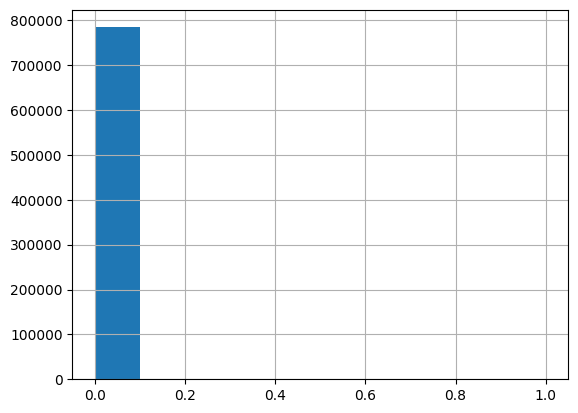

In [7]:
worth = modeling[modeling["worthy"] == 1]
not_worth = modeling[modeling["worthy"] == 0]

modeling["worthy"].hist()
print(
    f"Observations with worthy class: {len(worth)} ({len(worth)/modeling.shape[0]*100:.2f}%)"
)

In [8]:
X = modeling.drop(columns=["worthy"])
y = modeling["worthy"]

# Train/test split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TRAIN_TEST_SPLIT, stratify=y, random_state=RND_STATE
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((706782, 482), (78532, 482), (706782,), (78532,))

# Fit default model

In [10]:
MODEL_STATIC_PARAMS = {
    "seed": RND_STATE,
    "device_type": "gpu",
    "objective": "binary",
    "metric": "binary_logloss",
    "is_unbalance": True
}

In [11]:
default_lgbm_model = lgb.LGBMClassifier(**MODEL_STATIC_PARAMS)
default_lgbm_model.fit(X_train, y_train)

model_path = "models/default_cls_model.joblib"
joblib.dump(default_lgbm_model, model_path)

[LightGBM] [Info] Number of positive: 854, number of negative: 705928
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 121507
[LightGBM] [Info] Number of data points in the train set: 706782, number of used features: 482
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4060 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 482 dense feature groups (326.24 MB) transferred to GPU in 0.078326 secs. 0 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001208 -> initscore=-6.717337
[LightGBM] [Info] Start training from score -6.717337


['models/default_cls_model.joblib']

In [12]:
# Predict on the test set
y_pred = default_lgbm_model.predict(X_test)
y_pred_proba = default_lgbm_model.predict_proba(X_test)[:, 1]

In [13]:
# Calculate evaluation metrics
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)
mcc = matthews_corrcoef(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)

# Create a dictionary with the evaluation metrics and an additional 'Type' column
results = {
    'Type': ['default'],
    'F1 Score': [f1],
    'MCC': [mcc],
    'PR AUC': [pr_auc],
    'Balanced Accuracy': [balanced_acc],
    'Precision': [precision],
    'Recall': [recall],
    'AUC': [roc_auc],
}

DF_SCORES = pd.DataFrame(results)
print(DF_SCORES)

      Type  F1 Score       MCC    PR AUC  Balanced Accuracy  Precision  \
0  default  0.009355  0.043891  0.003815           0.731106   0.004713   

     Recall       AUC  
0  0.621053  0.686758  



Confusion Matrix:
[[65978 12459]
 [   36    59]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.84      0.91     78437
           1       0.00      0.62      0.01        95

    accuracy                           0.84     78532
   macro avg       0.50      0.73      0.46     78532
weighted avg       1.00      0.84      0.91     78532



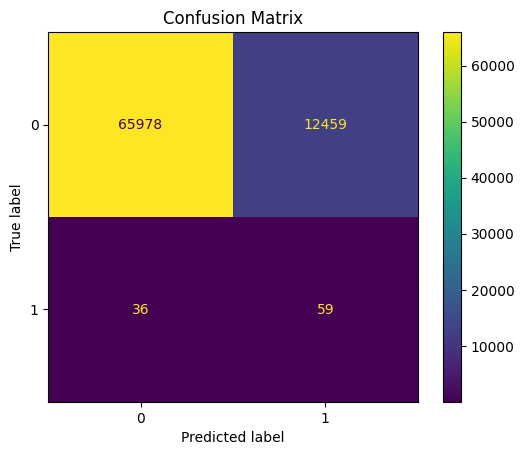

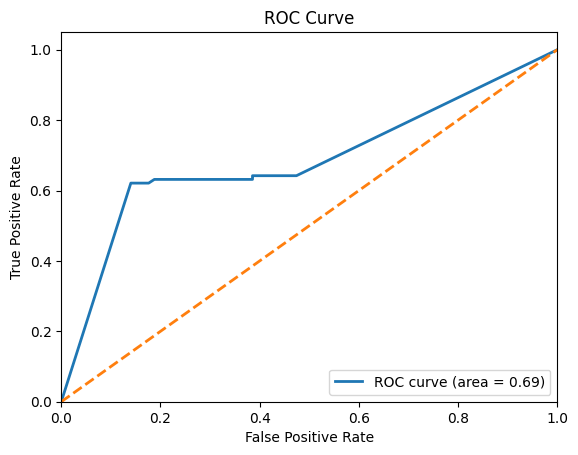

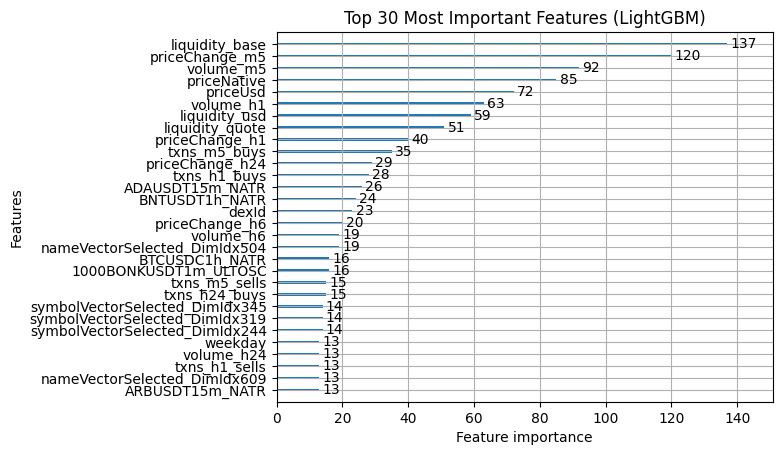

In [14]:
# Display confusion matrix and classification report
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc_curve = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, lw=2, label=f"ROC curve (area = {roc_auc_curve:.2f})")
plt.plot([0, 1], [0, 1], lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

# Plot LightGBM feature importance (by split count)
lgb.plot_importance(default_lgbm_model.booster_, max_num_features=30, importance_type="split")
plt.title("Top 30 Most Important Features (LightGBM)")
plt.show()

# Optuna hiperparameter optimization

In [42]:
opt_cv = StratifiedKFold(n_splits=HYPERPARAM_TUNING_NFOLDS,
                         shuffle=True,
                         random_state=RND_STATE)

## Sampler and pruner definition

In [43]:
sampler = TPESampler(
    seed=RND_STATE,
    multivariate=True,
    group=True,
    n_startup_trials=3,
    constant_liar=True,
)

pruner = HyperbandPruner(
    min_resource=1,
    max_resource='auto',
    reduction_factor=3
)

C:\Users\philipz\.pyenv\pyenv-win\versions\3.13.5\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
C:\Users\philipz\.pyenv\pyenv-win\versions\3.13.5\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  warnings.warn(
C:\Users\philipz\.pyenv\pyenv-win\versions\3.13.5\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``constant_liar`` is an experimental feature. The interface can change in the future.
  warnings.warn(


## Define objective

In [44]:
# Optuna objective: maximize PR-AUC (harmonic mean across folds)
def objective(trial):
    params = {
        **MODEL_STATIC_PARAMS,
        "n_estimators": trial.suggest_int("n_estimators", 100, 1_000),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.5, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 96),
        "max_depth": trial.suggest_int("max_depth", 4, 32),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 5, 35),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 0.95),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.7, 0.95),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 7),
        "lambda_l1": trial.suggest_float("lambda_l1", 0.0, 50.0),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.0, 50.0),
        "min_gain_to_split": trial.suggest_float("min_gain_to_split", 0.0, 5.0),
        # "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1, 500),
        "verbosity": -1,
    }
    f1_values, step = [], 0
    for tr_idx, va_idx in opt_cv.split(X_train, y_train):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        model = lgb.LGBMClassifier(**params)
        try:
            model.fit(X_tr, y_tr,
                      eval_set=[(X_va, y_va)],
                      callbacks=[lgb.early_stopping(50, verbose=True)])
            y_pred = model.predict(X_va)
            f1 = f1_score(y_va, y_pred)
        except (lgb.basic.LightGBMError, ValueError):
            raise optuna.TrialPruned()
        f1_values.append(f1)
        step += 1
        trial.report(f1, step=step)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(f1_values))

## Run study

In [45]:
# Run Optuna search (TPE + ASHA)
study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    pruner=pruner
)
study.optimize(objective,
               timeout=TERMINATION_OPTUNA,
               show_progress_bar=True)

[I 2025-09-23 05:48:32,469] A new study created in memory with name: no-name-dacebb41-7154-427e-813d-57452ca1591f
   0%|                                                                                                 | 00:00/16:00:00

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.128288
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.128463
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.129988
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.125168
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.130065


Best trial: 0. Best value: 0.0219919:    0%|                                                           | 01:00/16:00:00

[I 2025-09-23 05:49:32,602] Trial 0 finished with value: 0.02199193773051967 and parameters: {'n_estimators': 950, 'learning_rate': 0.017889040674015932, 'num_leaves': 31, 'max_depth': 20, 'min_data_in_leaf': 24, 'feature_fraction': 0.8394784061121109, 'bagging_fraction': 0.7258593887549994, 'bagging_freq': 6, 'lambda_l1': 14.098953503711797, 'lambda_l2': 37.67122935721416, 'min_gain_to_split': 3.96352814785358}. Best is trial 0 with value: 0.02199193773051967.
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.0826656
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.0804755
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.0820785
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 

Best trial: 0. Best value: 0.0219919:    0%|▏                                                          | 02:11/16:00:00

...

[I 2025-09-23 21:46:38,071] Trial 861 pruned. 
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.0171384
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.0168387
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.0173168


Best trial: 436. Best value: 0.0672084:  100%|█████████████████████████████████████████████████████▉| 15:58:47/16:00:00

[I 2025-09-23 21:47:19,915] Trial 862 pruned. 
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[470]	valid_0's binary_logloss: 0.0328456
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[470]	valid_0's binary_logloss: 0.0325817
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[470]	valid_0's binary_logloss: 0.0320605
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[470]	valid_0's binary_logloss: 0.0329267
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[470]	valid_0's binary_logloss: 0.0318385


Best trial: 436. Best value: 0.0672084:  100%|██████████████████████████████████████████████████████| 16:03:33/16:00:00

[I 2025-09-23 21:52:06,010] Trial 863 finished with value: 0.0649120336651762 and parameters: {'n_estimators': 470, 'learning_rate': 0.0215327101837048, 'num_leaves': 84, 'max_depth': 27, 'min_data_in_leaf': 6, 'feature_fraction': 0.7833034064071772, 'bagging_fraction': 0.9031139586765183, 'bagging_freq': 6, 'lambda_l1': 34.82413813891408, 'lambda_l2': 38.970954023152366, 'min_gain_to_split': 2.1050802737079475}. Best is trial 436 with value: 0.06720844136369306.


In [46]:
best_params = study.best_trial.params

In [47]:
# best_params = {'n_estimators': 294, 'learning_rate': 0.024975712822264934, 'num_leaves': 95, 'max_depth': 17, 'min_data_in_leaf': 17, 'feature_fraction': 0.6870313039016708, 'bagging_fraction': 0.915806368784476, 'bagging_freq': 4, 'lambda_l1': 49.54375112487054, 'lambda_l2': 19.197253135000512, 'min_gain_to_split': 1.7597150821339216, 'seed': 37, 'device_type': 'gpu', 'objective': 'binary', 'metric': 'binary_logloss', 'is_unbalance': True}

In [48]:
best_params.update(MODEL_STATIC_PARAMS)
print("Best params:", best_params)

Best params: {'n_estimators': 294, 'learning_rate': 0.024975712822264934, 'num_leaves': 95, 'max_depth': 17, 'min_data_in_leaf': 17, 'feature_fraction': 0.6870313039016708, 'bagging_fraction': 0.915806368784476, 'bagging_freq': 4, 'lambda_l1': 49.54375112487054, 'lambda_l2': 19.197253135000512, 'min_gain_to_split': 1.7597150821339216, 'seed': 37, 'device_type': 'gpu', 'objective': 'binary', 'metric': 'binary_logloss', 'is_unbalance': True}


## Fit optimized model

In [49]:
# Fit best LGBM on train (CUDA) and validate on test
lgbm_model = lgb.LGBMClassifier(random_state=RND_STATE, **best_params)
lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(200, verbose=True)]
)
os.makedirs("models", exist_ok=True)
joblib.dump(lgbm_model, "models/opt_cls_model.joblib")

Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[294]	valid_0's binary_logloss: 0.0458422


['models/opt_cls_model.joblib']

## Analyse opimal model

In [50]:
# Evaluate & log into DF_SCORES
y_pred = lgbm_model.predict(X_test)
y_proba = lgbm_model.predict_proba(X_test)[:, 1]

In [51]:
# Calculate evaluation metrics
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
mcc = matthews_corrcoef(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)

# Create a dictionary with the evaluation metrics and an additional 'Type' column
results = {
    'Type': ['default'],
    'F1 Score': [f1],
    'MCC': [mcc],
    'PR AUC': [pr_auc],
    'Balanced Accuracy': [balanced_acc],
    'Precision': [precision],
    'Recall': [recall],
    'AUC': [roc_auc],
}

DF_SCORES = pd.DataFrame(results)
print(DF_SCORES)

      Type  F1 Score     MCC    PR AUC  Balanced Accuracy  Precision  \
0  default  0.075286  0.1014  0.037752           0.621299   0.044146   

     Recall       AUC  
0  0.255556  0.930795  



Confusion Matrix:
[[75871   996]
 [  134    46]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     76867
           1       0.04      0.26      0.08       180

    accuracy                           0.99     77047
   macro avg       0.52      0.62      0.53     77047
weighted avg       1.00      0.99      0.99     77047



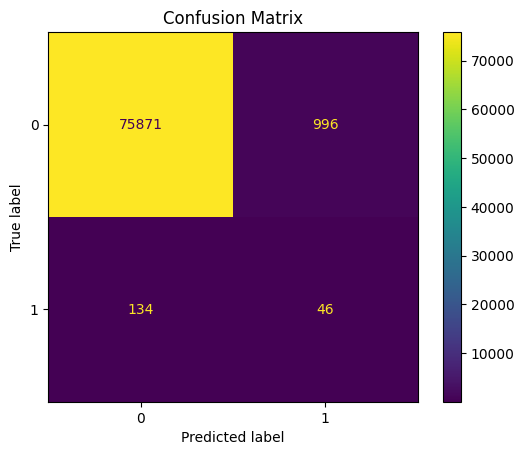

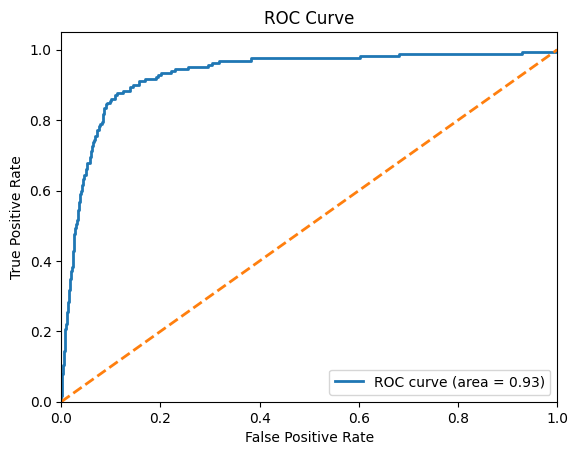

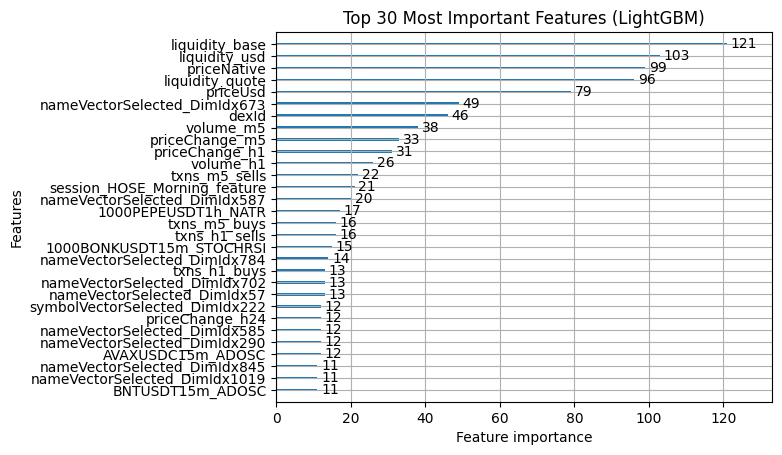

In [52]:
# Display confusion matrix and classification report
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc_curve = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, lw=2, label=f"ROC curve (area = {roc_auc_curve:.2f})")
plt.plot([0, 1], [0, 1], lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

# Plot LightGBM feature importance (by split count)
lgb.plot_importance(default_lgbm_model.booster_, max_num_features=30, importance_type="split")
plt.title("Top 30 Most Important Features (LightGBM)")
plt.show()

# Genetic hiperparameter optimization

## Define problem class

In [ ]:
class XGBoostOptimizationProblem(ElementwiseProblem):
    def __init__(self, x_data, y_data, scorer, cv_folds=5, rnd_state=None, **kwargs):
        self.x_data = x_data
        self.y_data = y_data
        self.cv_folds = cv_folds
        self.scorer = scorer
        self.rnd_state = rnd_state
        self.eval_times = []

        self.skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=rnd_state)
        
        hyperparameters = {
            "learning_rate": Real(bounds=(0.001, 0.3)),
            "max_depth": Integer(bounds=(2, 12)),
            "min_child_weight": Integer(bounds=(1, 20)),
            "subsample": Real(bounds=(0.5, 1.0)),
            "colsample_bytree": Real(bounds=(0.1, 1.0)),
            "colsample_bylevel": Real(bounds=(0.2, 1.0)),
            "colsample_bynode": Real(bounds=(0.2, 1.0)),
            "gamma": Real(bounds=(0, 10)),
            "reg_alpha": Real(bounds=(0, 50)),
            "reg_lambda": Real(bounds=(0, 50)),
            "scale_pos_weight": Real(bounds=(1, 300)),
            "max_delta_step": Integer(bounds=(0, 10)),
            "n_estimators": Integer(bounds=(100, 2000))
        }
        
        super().__init__(vars=hyperparameters, n_obj=1, **kwargs)

    def _evaluate(self, X, out, *args, **kwargs):
        start_time = time.time()
        
        model = XGBClassifier(
            device="cuda",
            eval_metric='logloss',
            tree_method='hist',
            learning_rate=X["learning_rate"],
            max_depth=X["max_depth"],
            min_child_weight=X["min_child_weight"],
            subsample=X["subsample"],
            colsample_bytree=X["colsample_bytree"],
            colsample_bylevel=X["colsample_bylevel"],
            colsample_bynode=X["colsample_bynode"],
            gamma=X["gamma"],
            reg_alpha=X["reg_alpha"],
            reg_lambda=X["reg_lambda"],
            scale_pos_weight=X["scale_pos_weight"],
            max_delta_step=X["max_delta_step"],
            n_estimators=X["n_estimators"],
            random_state=self.rnd_state
        )
        
        cv_scores = cross_val_score(
            model,
            self.x_data,
            self.y_data,
            cv=self.skf,
            scoring=self.scorer,
            n_jobs=1
        )
        
        # mean_score = np.mean(cv_scores)
        # mean_score = geometric_mean(cv_scores)
        mean_score = 0 if (np.array(cv_scores) <= 0).any() else len(np.array(cv_scores)) / np.sum(1 / np.array(cv_scores))
        
        eval_time = time.time() - start_time
        self.eval_times.append(eval_time)
        print(f'Params {X}')
        print(f'Mean CV score: {mean_score}  Evaluation time: {eval_time:.2f}s (mean {np.mean(self.eval_times):.2f}s)')
        print()
        out["F"] = -mean_score

## Run search

In [ ]:
# pool = Pool(cpu_count())
# runner = StarmapParallelization(pool.starmap)

problem = XGBoostOptimizationProblem(
    X_train,
    y_train,
    cv_folds=HYPERPARAM_TUNING_NFOLDS,
    scorer=SCORERS[HYPERPARAM_TUNING_SCORER],
    rnd_state=RND_STATE
)
algorithm = GA(
    pop_size=HYPERPARAM_TUNING_POPSIZE,
    sampling=MixedVariableSampling(),
    mating=MixedVariableMating(
        eliminate_duplicates=MixedVariableDuplicateElimination()
    ),
    eliminate_duplicates=MixedVariableDuplicateElimination(),
)

res = minimize(
    problem,
    algorithm,
    termination=TERMINATION,
    verbose=True,
)

In [ ]:
if len(res.F) == 1:
    if isinstance(res.X, dict):
        print(f"Best gene: reward= {-res.f} variables= {res.X.items()}")
    else:
        print(f"Best gene: reward= {-res.f} variables= {res.X}")
else:
    print("Pareto front:")
    for front, var in zip(res.F, res.X):
        print(f"front=", front, "variables=", list(var.values()))

## Fit tuned model

In [ ]:
tuned_xgb_model = XGBClassifier(device="cuda",
                                    tree_method='hist',
                                    random_state=RND_STATE,
                                    **res.X
                                   )

# tuned_xgb_model = XGBClassifier(device="cuda",
#                                 eval_metric='logloss',
#                                 tree_method='hist',
#                                 random_state=RND_STATE,
#                                 learning_rate=0.00109978690927931,
#                                 subsample=0.9216544748682952,
#                                 colsample_bytree=0.9635968738765436,
#                                 colsample_bylevel=0.45309242813093226,
#                                 colsample_bynode=0.8110104117864092,
#                                 gamma=6.730201205511014,
#                                 reg_alpha=42.049230617577955,
#                                 reg_lambda=2.2602518863252836,
#                                 scale_pos_weight=112.19349812588183,
#                                 max_depth=10,
#                                 min_child_weight=19,
#                                 max_delta_step=4,
#                                 n_estimators=596)

tuned_xgb_model.fit(X_train, y_train)
joblib.dump(tuned_xgb_model, "models/tuned_cls_model.joblib")

In [ ]:
# Predict on the test set
y_pred = tuned_xgb_model.predict(X_test)
y_pred_proba = tuned_xgb_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)
mcc = matthews_corrcoef(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)

# Print the metrics
print("SCORES:")
print(f"F1 Score:          {f1:.4f}")
print(f"MCC:               {mcc:.4f}")
print(f"PR AUC:            {pr_auc:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Precision:         {precision:.4f}")
print(f"Recall:            {recall:.4f}")
print(f"AUC:               {roc_auc:.4f}")

# Display confusion matrix and classification report
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc_curve = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {roc_auc_curve:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [ ]:
plt.figure(figsize=(10, 8))
plot_importance(
    tuned_xgb_model, max_num_features=25, importance_type="weight", show_values=True
)
plt.title("Top 20 Most Important Features (XGBoost)")
plt.show()

# Dataset balancer optimization

## Run search

In [ ]:
if BALANCE_DATASET:
    best_metric = -1
    best_method = None
    best_pipeline = None
    results = []
    
    for method_name, sampler in BALANCE_METHODS.items():
        pipeline = ImbPipeline([
            ('sampler', sampler),
            ('model', xgb.XGBClassifier(
                device="cuda",
                seed=RND_STATE,
                eval_metric='logloss',
                tree_method='hist',
                verbosity=2,
                **res.X
            ))
        ])
        
        cv = StratifiedKFold(n_splits=5,
                             shuffle=True,
                             random_state=RND_STATE)
        
        cv_results = cross_validate(
            estimator=pipeline,
            X=X_train,
            y=y_train,
            cv=cv,
            scoring=SCORERS,
            return_train_score=False,
            n_jobs=1
        )
        
        mean_scores = {
            'f1': np.mean(cv_results['test_f1']),
            'precision': np.mean(cv_results['test_precision']),
            'recall': np.mean(cv_results['test_recall']),
            'roc_auc': np.mean(cv_results['test_roc_auc']),
            'pr_auc': np.mean(cv_results['test_pr_auc']),
            'mcc': np.mean(cv_results['test_mcc']),
            'balanced_accuracy': np.mean(cv_results['test_balanced_accuracy'])
        }
        
        results.append({
            "Method": method_name,
            **mean_scores
        })
        
        print(f"Metoda: {method_name}")
        print(f"CV F1: {mean_scores['f1']:.4f}, PR AUC: {mean_scores['pr_auc']:.4f}, MCC: {mean_scores['mcc']:.4f}\n")
        
        if mean_scores[BALANCER_SCORER] > best_metric:
            best_metric = mean_scores[BALANCER_SCORER]
            best_method = method_name
            best_pipeline = pipeline

## Examine results

In [ ]:
if BALANCE_DATASET:
    # Podsumowanie wyników
    balancer_results = pd.DataFrame(results).sort_values(by=BALANCER_SCORER, ascending=False)
    print("\nPodsumowanie wyników walidacji krzyżowej:")
    print(balancer_results)

In [ ]:
if BALANCE_DATASET:
    BEST_SAMPLER = balancer_results['Method'].iloc[0]

In [ ]:
if BALANCE_DATASET:
    best_pipeline.fit(X_train, y_train)
    
    # balnced_model_filename = f"models/balanced_cls_model.joblib"
    # joblib.dump(best_pipeline, balnced_model_filename)

In [ ]:
if BALANCE_DATASET:
    y_pred = best_pipeline.predict(X_test)
    y_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]

In [ ]:
if BALANCE_DATASET:
    test_metrics = {
        "f1": f1_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_pred_proba),
        "pr_auc": average_precision_score(y_test, y_pred_proba),
        "mcc": matthews_corrcoef(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred)
    }
    
    print("\nWyniki na zbiorze testowym:")
    for metric, value in test_metrics.items():
        print(f"{metric}: {value:.4f}")

In [ ]:
if BALANCE_DATASET:
    # Calculate evaluation metrics
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)
    mcc = matthews_corrcoef(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    
    results = {
        'Type': BEST_SAMPLER,
        'F1 Score': f1,
        'MCC': mcc,
        'PR AUC': pr_auc,
        'Balanced Accuracy': balanced_acc,
        'Precision': precision,
        'Recall': recall,
        'AUC': roc_auc,
    }
    
    # Dodajemy nowy wiersz do DataFrame
    DF_SCORES.loc[len(DF_SCORES)] = results
    
    # Wyświetlamy DataFrame z dodanym wierszem
    print(DF_SCORES)

In [ ]:
if BALANCE_DATASET:
    # Display confusion matrix and classification report
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title("Confusion Matrix")
    plt.show()
    
    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc_curve = auc(fpr, tpr)
    
    plt.figure()
    plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {roc_auc_curve:.2f})")
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.show()

In [ ]:
if BALANCE_DATASET:
    plt.figure(figsize=(10, 8))
    plot_importance(
        best_pipeline.named_steps['model'], max_num_features=25, importance_type="weight", show_values=True
    )
    plt.title("Top 20 Most Important Features (XGBoost)")
    plt.show()

# Final model

In [53]:
X_final_train, X_final_test, y_final_train, y_final_test = train_test_split(
    X, y, test_size=0.01, stratify=y, random_state=RND_STATE
)

In [54]:
X_res_final_train, y_res_final_train = BALANCE_METHODS[BEST_SAMPLER].fit_resample(X_final_train, y_final_train)

In [55]:
final_lgbm_model = lgb.LGBMClassifier(**best_params)

final_lgbm_model.fit(X_res_final_train, y_res_final_train)
joblib.dump(final_lgbm_model, "models/final_cls_model.joblib")

NameError: name 'final_xgb_model' is not defined

SCORES:
F1 Score:          0.0896
MCC:               0.1265
PR AUC:            0.0555
Balanced Accuracy: 0.6595
Precision:         0.0517
Recall:            0.3333
AUC:               0.9393

Confusion Matrix:
[[7577  110]
 [  12    6]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      7687
           1       0.05      0.33      0.09        18

    accuracy                           0.98      7705
   macro avg       0.53      0.66      0.54      7705
weighted avg       1.00      0.98      0.99      7705



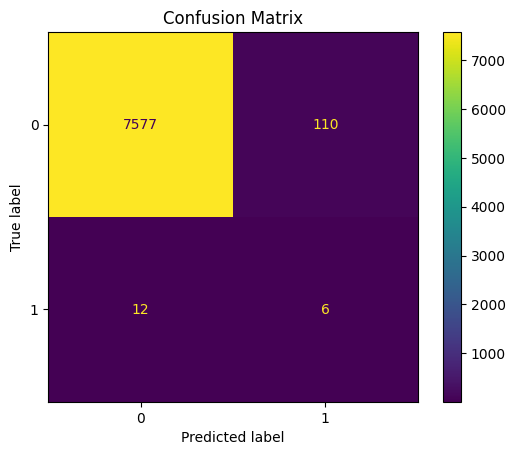

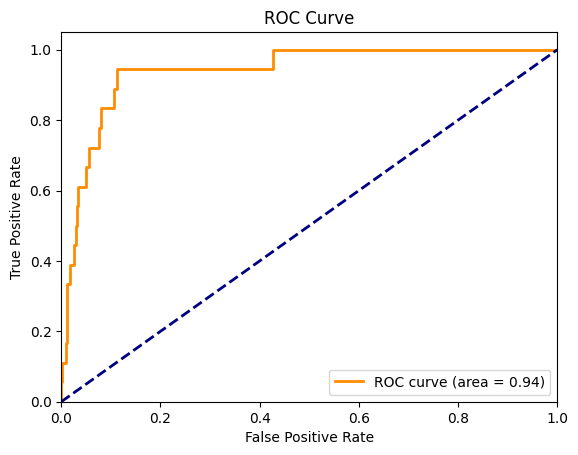

In [57]:
# Predict on the test set
y_pred = final_lgbm_model.predict(X_final_test)
y_pred_proba = final_lgbm_model.predict_proba(X_final_test)[:, 1]

# Calculate evaluation metrics
f1 = f1_score(y_final_test, y_pred)
precision = precision_score(y_final_test, y_pred, zero_division=0)
recall = recall_score(y_final_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_final_test, y_pred_proba)
pr_auc = average_precision_score(y_final_test, y_pred_proba)
mcc = matthews_corrcoef(y_final_test, y_pred)
balanced_acc = balanced_accuracy_score(y_final_test, y_pred)

# Print the metrics
print("SCORES:")
print(f"F1 Score:          {f1:.4f}")
print(f"MCC:               {mcc:.4f}")
print(f"PR AUC:            {pr_auc:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Precision:         {precision:.4f}")
print(f"Recall:            {recall:.4f}")
print(f"AUC:               {roc_auc:.4f}")

# Display confusion matrix and classification report
cm = confusion_matrix(y_final_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_final_test, y_pred))

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_final_test, y_pred_proba)
roc_auc_curve = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {roc_auc_curve:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

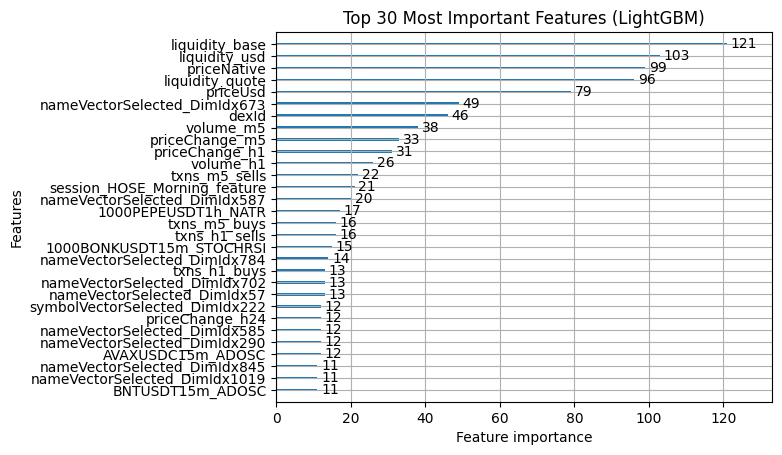

In [60]:
# Plot LightGBM feature importance (by split count)
lgb.plot_importance(default_lgbm_model.booster_, max_num_features=30, importance_type="split")
plt.title("Top 30 Most Important Features (LightGBM)")
plt.show()